# Resume Parsing System — Model Training & Evaluation

**NLP Project | Resume Classification using LSTM & Transformers**

### What this notebook does
We have a dataset of real-world resumes, each labeled with a job category (e.g., *Data Scientist*, *Java Developer*).
The goal is to train two different models that automatically predict which job category a resume belongs to.

| Step | What we do | Why |
|------|-----------|-----|
| 1 | Load & explore the dataset | Understand class balance, text lengths, missing data |
| 2 | Clean the text | Remove noise (URLs, emails, stopwords) so the model sees only meaningful words |
| 3 | Train a **BiLSTM** model | Lightweight, fast, great baseline |
| 4 | Train a **DistilBERT** model | Pre-trained transformer — understands language context |
| 5 | Compare both models | Accuracy, per-class F1, confusion matrices |
| 6 | Run predictions on a new resume | See the system in action |

## 0. Setup & Imports

We import everything upfront so missing packages fail fast.
- **`sys.path.insert`** — lets us import from `../src/` without installing the package as a library
- **`ResumeClassifier`** — wraps both models under one `.train()` / `.evaluate()` / `.predict()` API
- **`clean_text`** — the text preprocessing pipeline used consistently during training *and* inference (same function = no train/test skew)

In [1]:
# Install dependencies if needed
# !pip install tensorflow transformers scikit-learn pandas matplotlib seaborn

import warnings
warnings.filterwarnings('ignore')

import subprocess, sys, os
from pathlib import Path
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
import tensorflow as tf

from preprocess import clean_text
from classifier import ResumeClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Consistent visual style for all plots in this notebook
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
os.makedirs('../docs', exist_ok=True)

dataset_path = Path('../data/resume_dataset.csv')
if not dataset_path.exists():
    raise FileNotFoundError(f'Dataset not found at {dataset_path}. Place Resume.csv at data/resume_dataset.csv')

print('All imports successful!')
print(f'Dataset path: {dataset_path.resolve()}')

All imports successful!
Dataset path: /Users/aaa/Downloads/archive/Resume/Resume.csv


## 1. Dataset Exploration

Before training any model, we **understand the data**:
- How many resumes? Are classes balanced? (imbalanced classes hurt performance)
- How long are resumes? (affects the `MAX_LEN=300` token cutoff in the LSTM)
- Is there missing data? (NaNs in the text column → empty strings → the model learns nothing)

Skipping EDA is the #1 mistake in NLP projects — you end up tuning the wrong things.

In [2]:
# ── Load dataset ──────────────────────────────────────────────────────────
# pd.read_csv handles encoding issues automatically.
# Column names are detected dynamically because Kaggle CSVs sometimes
# have invisible BOM characters (\ufeff) at the start of column names.

df = pd.read_csv('../data/resume_dataset.csv')

# Detect label column (handles BOM prefix & different naming conventions)
possible_label = [c for c in df.columns
                  if any(k in c.lower() for k in ['category', 'label', 'position'])]
if not possible_label:
    raise ValueError('Label column not found. Columns: ' + str(list(df.columns)))
label_col = possible_label[0]
df['Category'] = df[label_col]

# Detect text column
text_col = next(
    (c for c in df.columns if any(k in c.lower() for k in ['resume', 'text', 'objective'])),
    None
)
if text_col is None:
    raise ValueError('Text column not found. Columns: ' + str(list(df.columns)))

print(f"Label column : '{label_col}'")
print(f"Text  column : '{text_col}'")
print(f"\nDataset shape    : {df.shape}")
print(f"Unique categories: {df['Category'].nunique()}")
print(f"Missing text     : {df[text_col].isna().sum()}")
df[[text_col, 'Category']].head(3)

Label column : 'Category'
Text  column : 'Resume_str'

Dataset shape    : (2484, 4)
Unique categories: 24
Missing text     : 0


,Resume_str,Category
0,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,HR
1,"HR SPECIALIST, US HR OPERATIONS ...",HR
2,HR DIRECTOR Summary Over 2...,HR


In [3]:
# ── Category distribution ─────────────────────────────────────────────────
# A well-balanced dataset means each category has roughly the same number of samples.
# Severe imbalance biases the model toward common classes.
# The classifier already mitigates this by filtering rare classes (< MIN_SAMPLES_PER_CLASS).

cat_counts = df['Category'].value_counts()
print(f'Category distribution ({len(cat_counts)} unique categories):')
print(cat_counts.to_string())
print(f'\nMost common  : {cat_counts.index[0]}  ({cat_counts.iloc[0]} samples)')
print(f'Least common : {cat_counts.index[-1]}  ({cat_counts.iloc[-1]} samples)')

Category distribution (24 unique categories):
Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
FINANCE                   118
ADVOCATE                  118
ACCOUNTANT                118
ENGINEERING               118
CHEF                      118
AVIATION                  117
FITNESS                   117
SALES                     116
BANKING                   115
HEALTHCARE                115
CONSULTANT                115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22

Most common  : INFORMATION-TECHNOLOGY  (120 samples)
Least common : BPO  (22 samples)


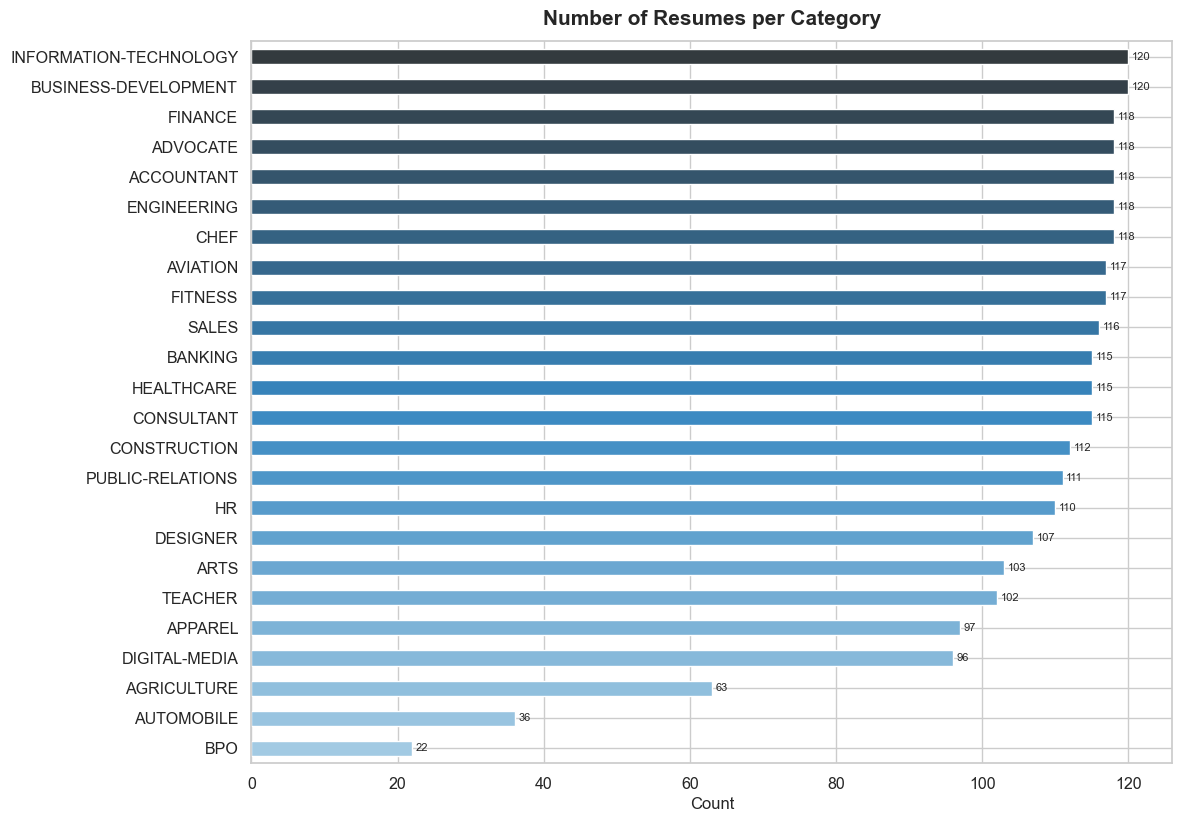

[Saved] ../docs/label_distribution.png


In [4]:
# ── Plot 1: Category Distribution (Horizontal Bar Chart) ──────────────────
# Horizontal bars are easier to read when category names are long strings.
# Sorted descending so the longest bar appears at the top.

fig, ax = plt.subplots(figsize=(12, max(6, len(cat_counts) * 0.35)))
colors = sns.color_palette('Blues_d', len(cat_counts))
cat_counts.sort_values().plot(kind='barh', ax=ax, color=colors)

ax.set_title('Number of Resumes per Category', fontsize=15, fontweight='bold', pad=12)
ax.set_xlabel('Count', fontsize=12)
ax.set_ylabel('')

# Add exact count labels at the end of each bar
for bar, val in zip(ax.patches, cat_counts.sort_values().values):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            str(val), va='center', fontsize=8)

plt.tight_layout()
plt.savefig('../docs/label_distribution.png', dpi=150)
plt.show()
print('[Saved] ../docs/label_distribution.png')

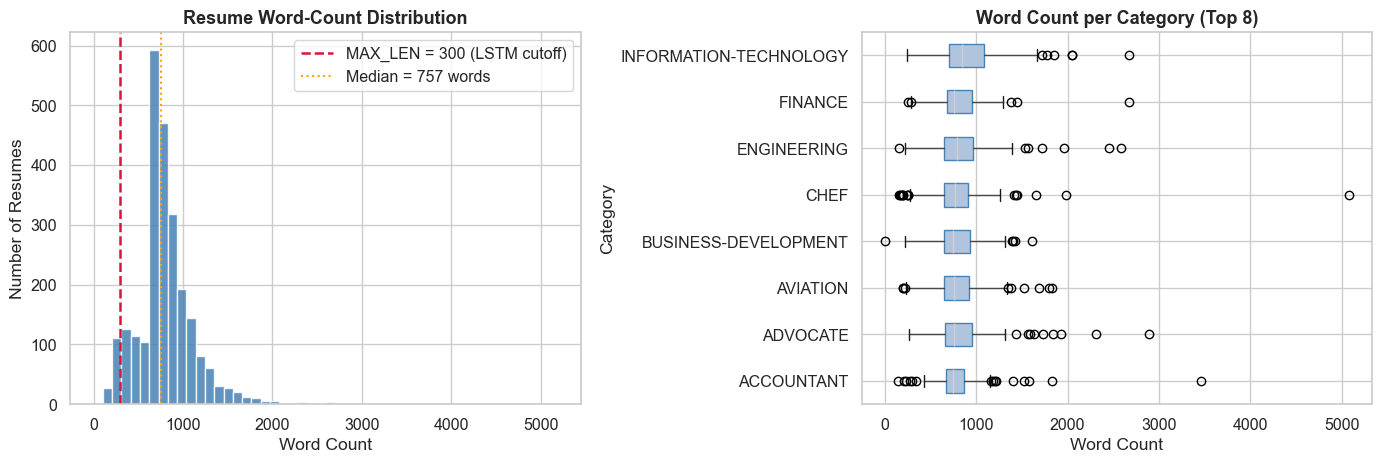

Resumes longer than 300 words (truncated by LSTM): 95.1%
[Saved] ../docs/text_length_distribution.png


In [5]:
# ── Plot 2: Resume Text Length Distribution ───────────────────────────────
# Why this matters: the LSTM truncates resumes at MAX_LEN=300 tokens.
# If most resumes are longer than 300 words, we lose significant content.
# This histogram shows whether 300 is a reasonable cutoff.

df['word_count'] = df[text_col].fillna('').astype(str).apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: overall histogram of all resume lengths
axes[0].hist(df['word_count'], bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(300, color='crimson', linestyle='--', linewidth=1.8,
                label=f'MAX_LEN = 300 (LSTM cutoff)')
axes[0].axvline(df['word_count'].median(), color='orange', linestyle=':', linewidth=1.5,
                label=f'Median = {df["word_count"].median():.0f} words')
axes[0].set_title('Resume Word-Count Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Number of Resumes')
axes[0].legend()

# Right: box plot per top-8 categories (shows spread and outliers within each class)
top8 = cat_counts.head(8).index.tolist()
df_top8 = df[df['Category'].isin(top8)].copy()
df_top8.boxplot(column='word_count', by='Category', ax=axes[1],
                vert=False, patch_artist=True,
                boxprops=dict(facecolor='lightsteelblue', color='steelblue'))
axes[1].set_title('Word Count per Category (Top 8)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Word Count')
plt.suptitle('')  # remove the auto-generated suptitle from boxplot

plt.tight_layout()
plt.savefig('../docs/text_length_distribution.png', dpi=150)
plt.show()

pct_over = (df['word_count'] > 300).mean() * 100
print(f'Resumes longer than 300 words (truncated by LSTM): {pct_over:.1f}%')
print('[Saved] ../docs/text_length_distribution.png')

In [6]:
# ── Missing Data Check ────────────────────────────────────────────────────
# NaN in the text column → clean_text('nan') → garbage tokens
# We report the count so the reader knows what to expect.

null_counts = df[[text_col, 'Category']].isnull().sum()
print('Missing values:')
for col, cnt in null_counts.items():
    status = '✓  None' if cnt == 0 else f'⚠️  {cnt}'
    print(f'  {col:25s}: {status}')

Missing values:
  Resume_str               : ✓  None
  Category                 : ✓  None


## 2. Text Preprocessing

Raw resume text is messy: URLs, email addresses, phone numbers, punctuation, numbers, and stop words all add noise without adding meaning.

**`clean_text()` pipeline** (see `src/preprocess.py`):

| Step | What it removes | Example |
|------|----------------|---------|
| Lowercase | — | `Python` → `python` |
| Remove URLs | `https://...` | `https://github.com/...` → `` |
| Remove emails | `user@domain.com` | `john@gmail.com` → `` |
| Remove phones | digit sequences | `+1 (555) 123-4567` → `` |
| Remove special chars | except `+` `#` | `C++, C#` preserved |
| Remove lone digits | years, IDs | `2019`, `42` → `` |
| Remove stopwords | function words | `the`, `and`, `is` → `` |
| Remove 1-char tokens | | `a`, `i` → `` |

After cleaning, only **discriminative keywords** remain — the words that actually distinguish one job category from another.

In [7]:
# ── Show raw vs cleaned text for one resume ───────────────────────────────
sample_raw   = str(df[text_col].iloc[0])
sample_clean = clean_text(sample_raw)

print('=== RAW TEXT (first 500 chars) ===')
print(sample_raw[:500])
print()
print('=== CLEANED TEXT (first 500 chars) ===')
print(sample_clean[:500])
print()
raw_wc   = len(sample_raw.split())
clean_wc = len(sample_clean.split())
print(f'Raw length   : {raw_wc} words')
print(f'Clean length : {clean_wc} words')
print(f'Reduction    : {100*(1 - clean_wc/max(raw_wc,1)):.0f}% of tokens removed as noise')

=== RAW TEXT (first 500 chars) ===
         HR ADMINISTRATOR/MARKETING ASSOCIATE

HR ADMINISTRATOR       Summary     Dedicated Customer Service Manager with 15+ years of experience in Hospitality and Customer Service Management.   Respected builder and leader of customer-focused teams; strives to instill a shared, enthusiastic commitment to customer service.         Highlights         Focused on customer satisfaction  Team management  Marketing savvy  Conflict resolution techniques     Training and development  Skilled multi-task

=== CLEANED TEXT (first 500 chars) ===
hr administrator marketing associate hr administrator summary dedicated customer service manager years experience hospitality customer service management respected builder leader customer focused teams strives instill shared enthusiastic commitment customer service highlights focused customer satisfaction team management marketing savvy conflict resolution techniques training development skilled multi tasker client relat

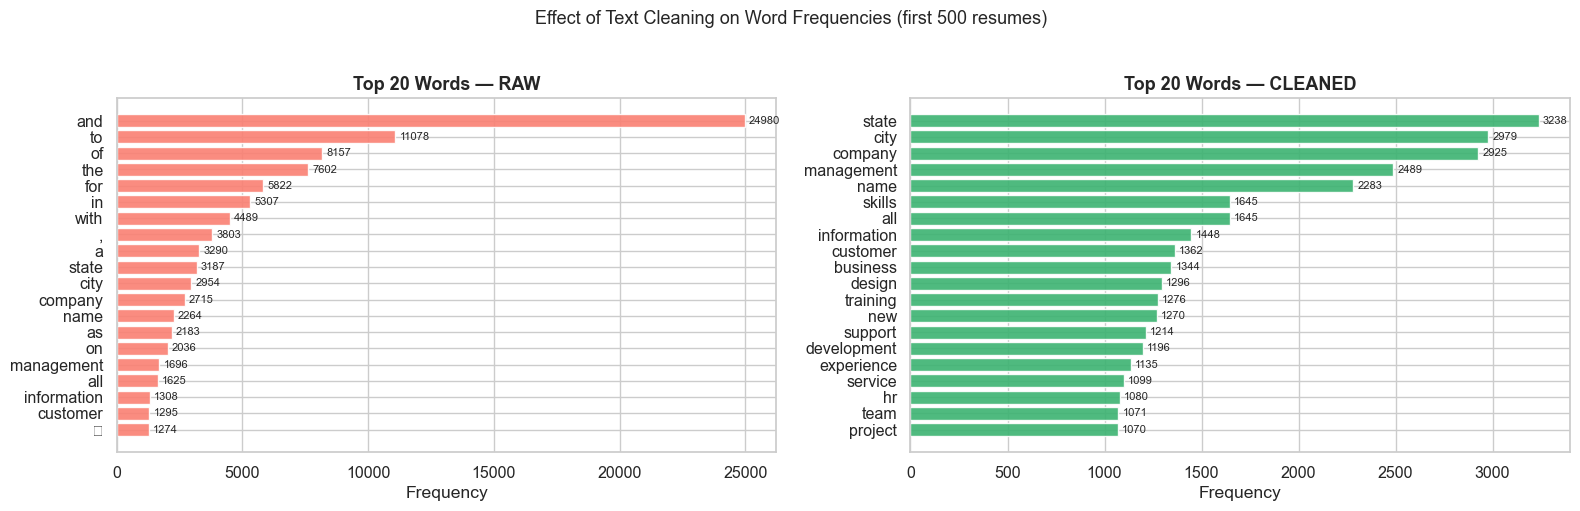

[Saved] ../docs/word_freq_before_after.png


In [8]:
# ── Plot 3: Top-20 Words Before vs After Cleaning ─────────────────────────
# The contrast makes the preprocessing value concrete:
# Before: dominated by stopwords ('and', 'the', 'to', 'of')
# After : only meaningful keywords ('python', 'experience', 'management')

# Use first 500 resumes to keep this fast
sample_df = df.dropna(subset=[text_col]).head(500)

raw_words   = ' '.join(sample_df[text_col].astype(str)).lower().split()
clean_words = ' '.join(sample_df[text_col].astype(str).apply(clean_text)).split()

top_raw   = Counter(raw_words).most_common(20)
top_clean = Counter(clean_words).most_common(20)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, title, data, color in [
    (axes[0], 'Top 20 Words — RAW',     top_raw,   'salmon'),
    (axes[1], 'Top 20 Words — CLEANED', top_clean, 'mediumseagreen'),
]:
    words, counts = zip(*data)
    bars = ax.barh(list(words)[::-1], list(counts)[::-1], color=color, edgecolor='white', alpha=0.9)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Frequency')
    ax.bar_label(bars, padding=3, fontsize=8)

plt.suptitle('Effect of Text Cleaning on Word Frequencies (first 500 resumes)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../docs/word_freq_before_after.png', dpi=150, bbox_inches='tight')
plt.show()
print('[Saved] ../docs/word_freq_before_after.png')

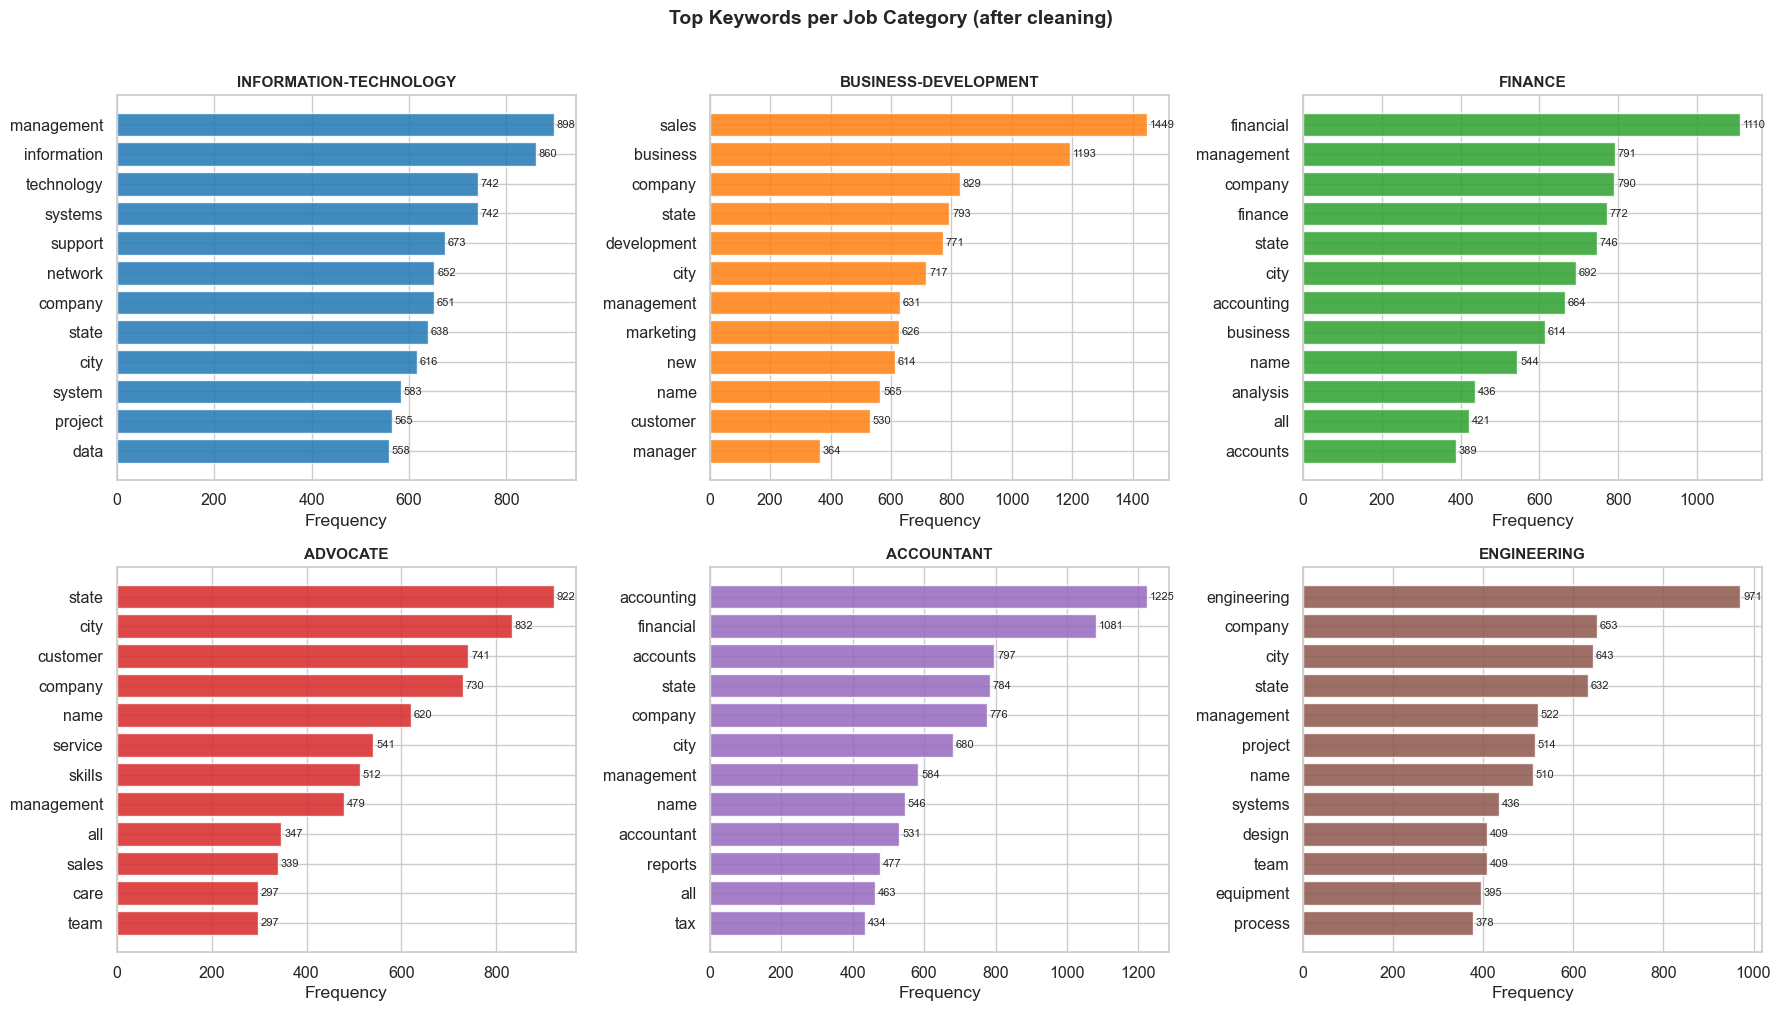

[Saved] ../docs/top_keywords_per_category.png


In [9]:
# ── Plot 4: Top Keywords per Job Category ─────────────────────────────────
# Each job category has a distinct vocabulary fingerprint.
# A Data Scientist resume is rich in 'python', 'model', 'machine', 'learning'.
# A Java Developer resume is rich in 'java', 'spring', 'api', 'maven'.
# This confirms that clean_text() preserves the discriminative signal the model needs.

top_cats = cat_counts.head(6).index.tolist()
palette  = sns.color_palette('tab10', 6)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (ax, cat) in enumerate(zip(axes, top_cats)):
    cat_texts = df[df['Category'] == cat][text_col].dropna().astype(str)
    cleaned   = ' '.join(cat_texts.apply(clean_text))
    top_words = Counter(cleaned.split()).most_common(12)
    if not top_words:
        ax.set_visible(False)
        continue
    words, counts = zip(*top_words)
    bars = ax.barh(list(words)[::-1], list(counts)[::-1],
                   color=palette[i], edgecolor='white', alpha=0.85)
    ax.set_title(cat, fontsize=11, fontweight='bold')
    ax.set_xlabel('Frequency')
    ax.bar_label(bars, padding=2, fontsize=8)

for ax in axes[len(top_cats):]:
    ax.set_visible(False)

plt.suptitle('Top Keywords per Job Category (after cleaning)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../docs/top_keywords_per_category.png', dpi=150, bbox_inches='tight')
plt.show()
print('[Saved] ../docs/top_keywords_per_category.png')

## 3. LSTM Model — Training

### Why Bidirectional LSTM?
A standard LSTM reads text **left-to-right**. A **Bidirectional** LSTM reads it in **both directions simultaneously**, so each token has access to its full left *and* right context.

Example: *"Python developer with 5 years"*
- Left-to-right LSTM sees `Python` before knowing it's followed by `developer`
- BiLSTM sees both directions at once → understands `Python` is a programming language here, not the snake

### Architecture
```
Input (padded word-index sequence, length = 300)
  ↓
Embedding layer (10,000-word vocab → 128-dimensional vectors)
  ↓
BiLSTM (128 units each direction, return_sequences=True)   ← captures local phrase patterns
  ↓  Dropout(0.3)
BiLSTM (64 units each direction)                           ← captures global structure
  ↓  Dropout(0.3)
Dense(128, ReLU)
  ↓  Dropout(0.3)
Dense(num_classes, Softmax)  ← probability over job categories
```

### Key hyperparameters
| Parameter | Value | Why |
|-----------|-------|-----|
| MAX_LEN | 300 | Covers most resumes without excessive padding |
| Dropout | 0.3 | Prevents overfitting on limited data |
| EarlyStopping patience=3 | | Stops when val_accuracy plateaus; restores best weights |
| Optimizer | Adam | Adaptive learning rate, robust default |

In [10]:
# Initialize and train the LSTM classifier.
# ResumeClassifier internally handles:
#   1. Loading & cleaning the CSV
#   2. Filtering rare categories (< 15 samples)
#   3. Building the tokenizer on training data ONLY (no data leakage)
#   4. Padding sequences to MAX_LEN=300
#   5. Building and fitting the BiLSTM model with EarlyStopping

lstm_clf = ResumeClassifier(model_type='lstm')
lstm_clf.train('../data/resume_dataset.csv')

[✓] Loaded 2484 resumes
    Text column  : Resume_str
    Label column : Category
    Raw classes  : 24



[filter] Removed 2 duplicate resumes
[filter] Remaining: 2482 unique resumes
[filter] Dropped classes with < 15 samples
[filter] Classes remaining: 24 (was 24)
[filter] Resumes remaining: 2482
[filter] Kept top 25 classes by frequency
[filter] Final dataset: 2482 resumes, 24 classes

Final class distribution:
----------------------------------------
  INFORMATION-TECHNOLOGY          120  ████████████████████████
  BUSINESS-DEVELOPMENT            120  ████████████████████████
  ADVOCATE                        118  ███████████████████████
  ACCOUNTANT                      118  ███████████████████████
  ENGINEERING                     118  ███████████████████████
  CHEF                            118  ███████████████████████
  FINANCE                         117  ███████████████████████
  FITNESS                         117  ███████████████████████
  AVIATION                        116  ███████████████████████
  SALES                           116  ███████████████████████
  BANKING      

2026-05-12 03:03:29.663282: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M5
2026-05-12 03:03:29.663305: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-05-12 03:03:29.663310: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-05-12 03:03:29.663327: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-05-12 03:03:29.663337: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "sequential"


_________________________________________________________________


...

Restoring model weights from the end of the best epoch: 6.



Epoch 9: val_accuracy did not improve from 0.67807


63/63 [==============================] - 4s 61ms/step - loss: 0.1853 - accuracy: 0.9531 - val_loss: 1.6828 - val_accuracy: 0.6761


Epoch 9: early stopping



[✓] Training complete. Artifacts saved to /Users/aaa/Desktop/uni/Resume-Parsing-System-clone/models/


## 4. LSTM Model — Evaluation

We evaluate on the **held-out test set** (20% of data, stratified — never seen during training).

Four evaluation dimensions:
1. **Overall accuracy** — the headline number, easy to compare
2. **Per-class precision / recall / F1** — reveals which categories the model struggles with
3. **Confusion matrix** — shows *which* categories get confused with each other (often similar job titles)
4. **Training curves** — loss & accuracy per epoch; a large gap between train and val signals overfitting

Accuracy alone is insufficient — if DevOps Engineer is always misclassified but represents only 5% of the test set, accuracy barely changes. F1-score captures this.

 1/16 [>.............................] - ETA: 5s

 4/16 [======>.......................] - ETA: 0s

 7/16 [============>.................] - ETA: 0s

10/16 [=================>............] - ETA: 0s

13/16 [=======================>......] - ETA: 0s

16/16 [==============================] - ETA: 0s

16/16 [==============================] - 1s 19ms/step



  TEST ACCURACY : 67.81%

Classification Report:
                        precision    recall  f1-score   support

            ACCOUNTANT       0.79      0.96      0.87        24
              ADVOCATE       0.68      0.79      0.73        24
           AGRICULTURE       0.50      0.31      0.38        13
               APPAREL       0.33      0.26      0.29        19
                  ARTS       0.25      0.57      0.35        21
            AUTOMOBILE       0.00      0.00      0.00         7
              AVIATION       0.44      0.30      0.36        23
               BANKING       0.53      0.35      0.42        23
                   BPO       0.00      0.00      0.00         4
  BUSINESS-DEVELOPMENT       0.83      1.00      0.91        24
                  CHEF       0.95      0.75      0.84        24
          CONSTRUCTION       0.76      0.73      0.74        22
            CONSULTANT       0.85      1.00      0.92        23
              DESIGNER       0.95      0.86      0.90

[✓] Saved: /Users/aaa/Desktop/uni/Resume-Parsing-System-clone/docs/confusion_matrix_lstm.png


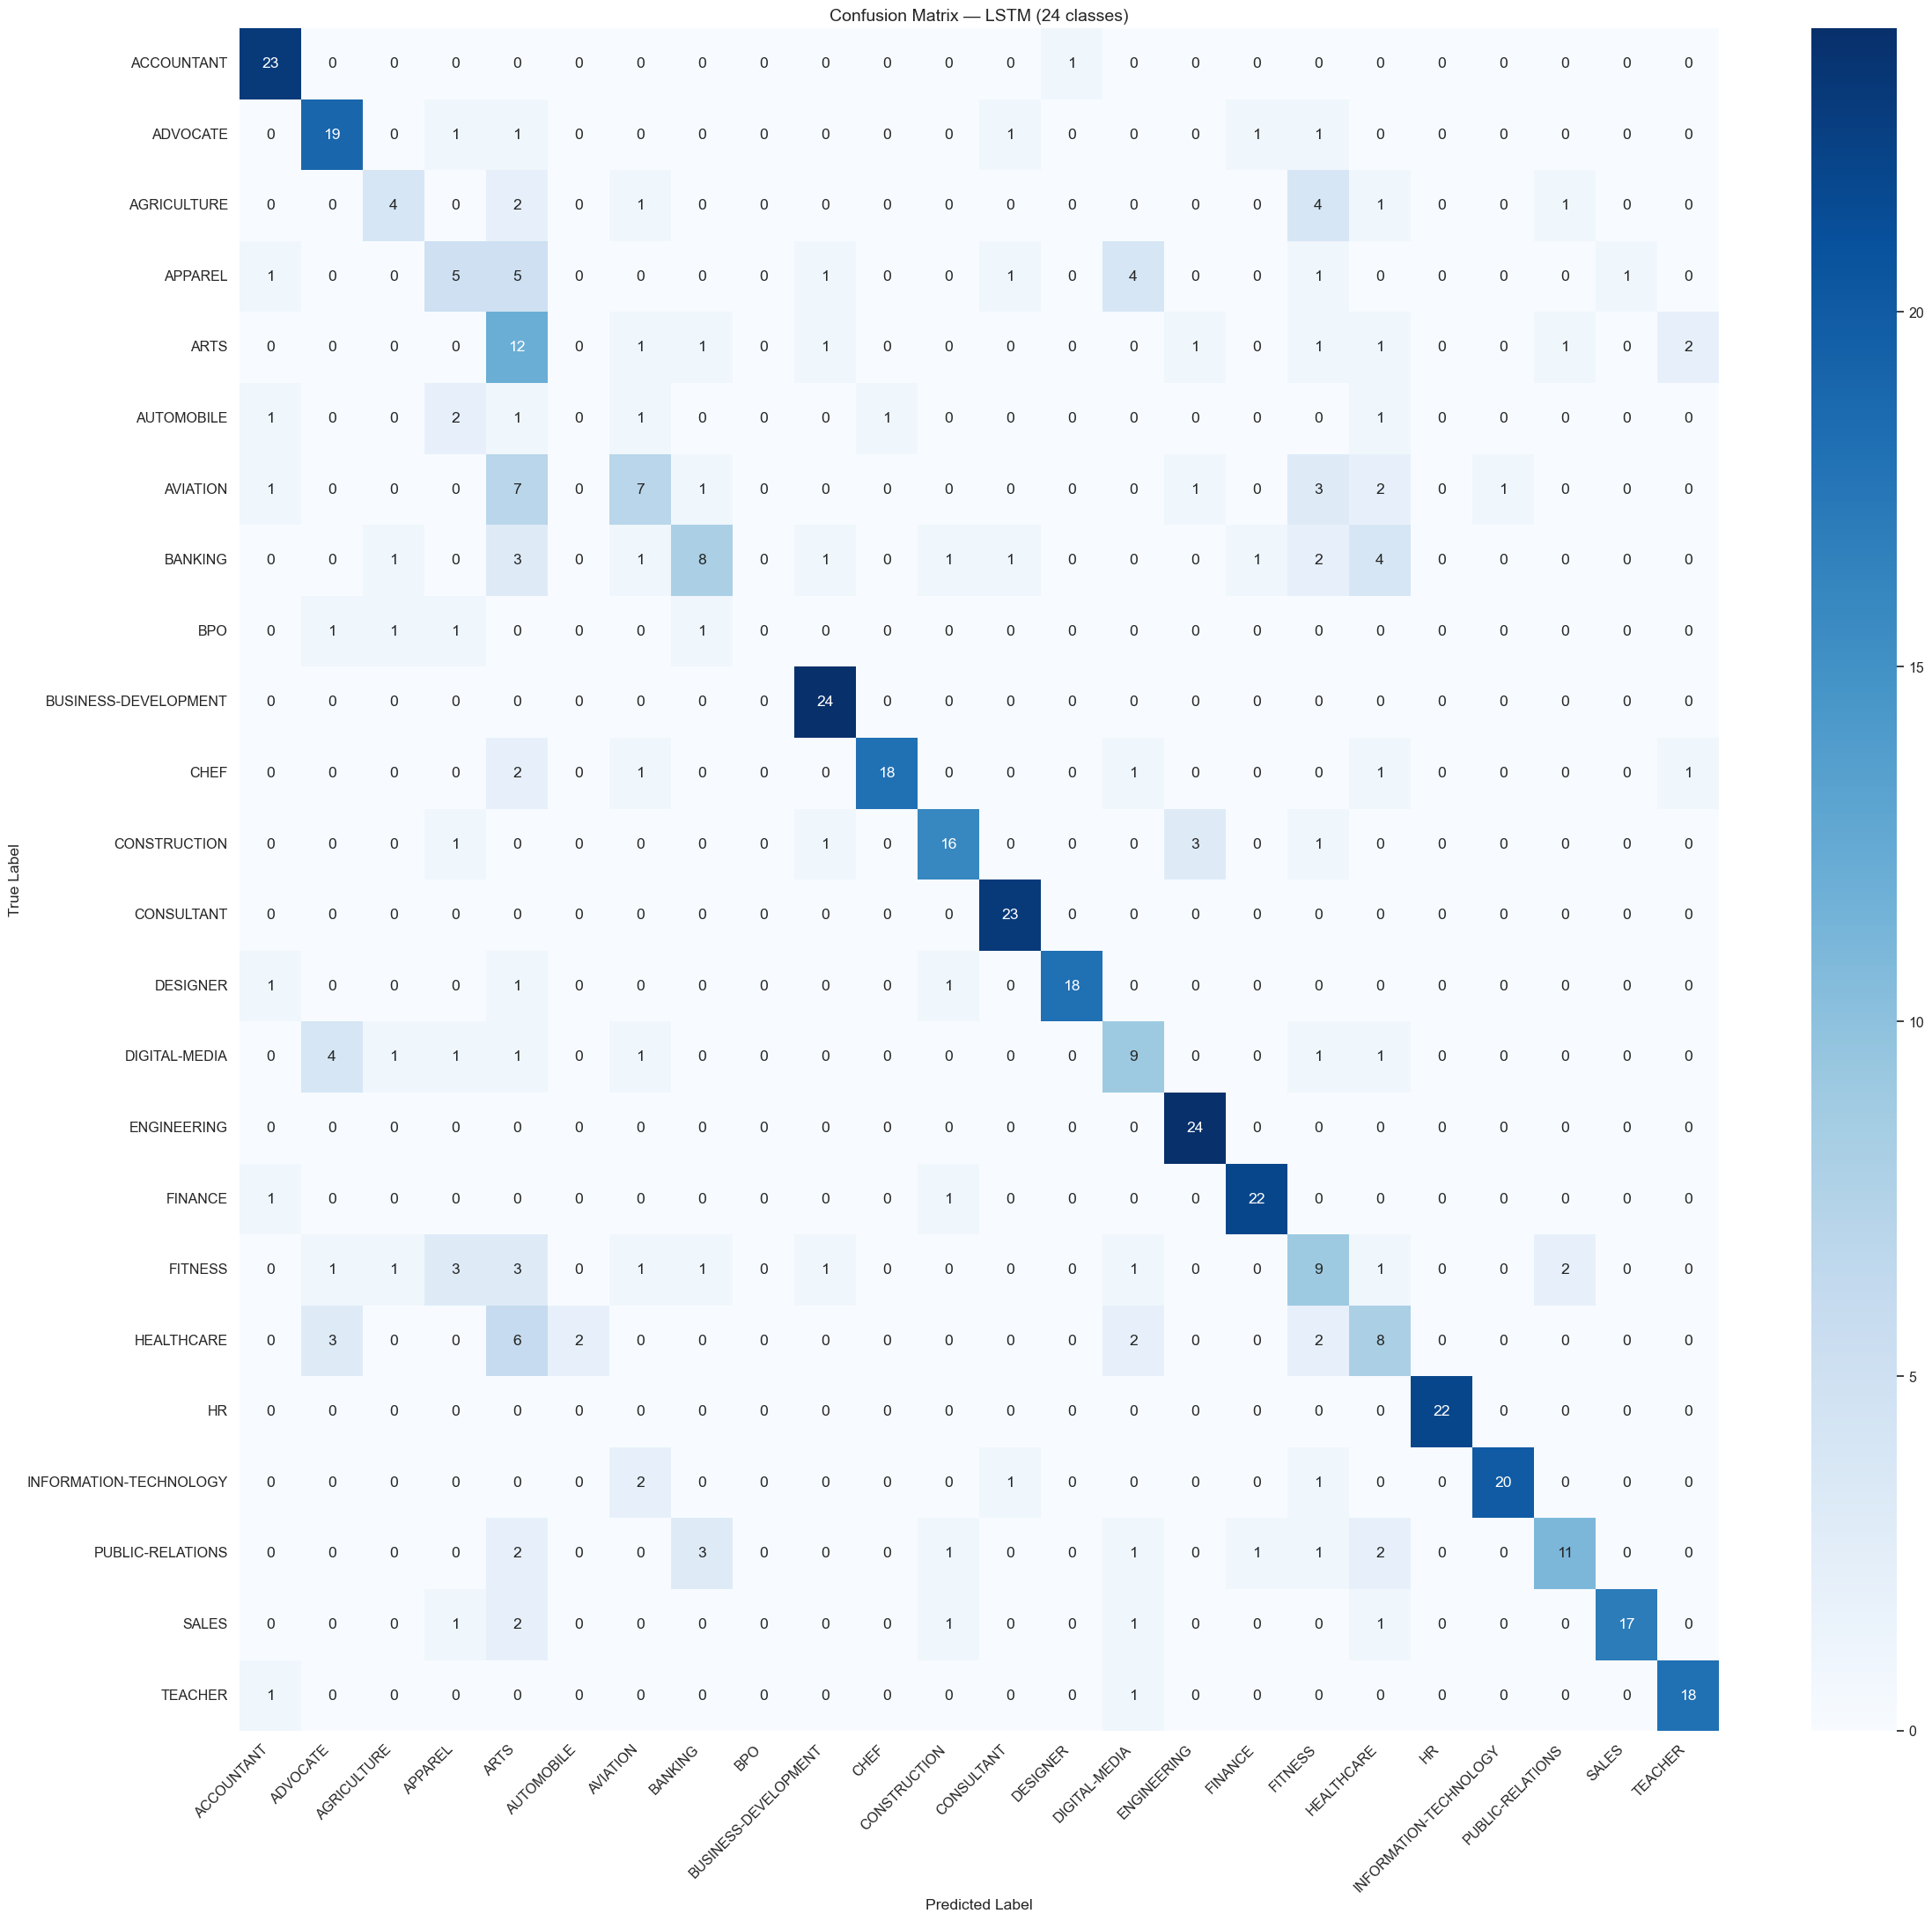

[✓] Saved: /Users/aaa/Desktop/uni/Resume-Parsing-System-clone/docs/training_curves_lstm.png


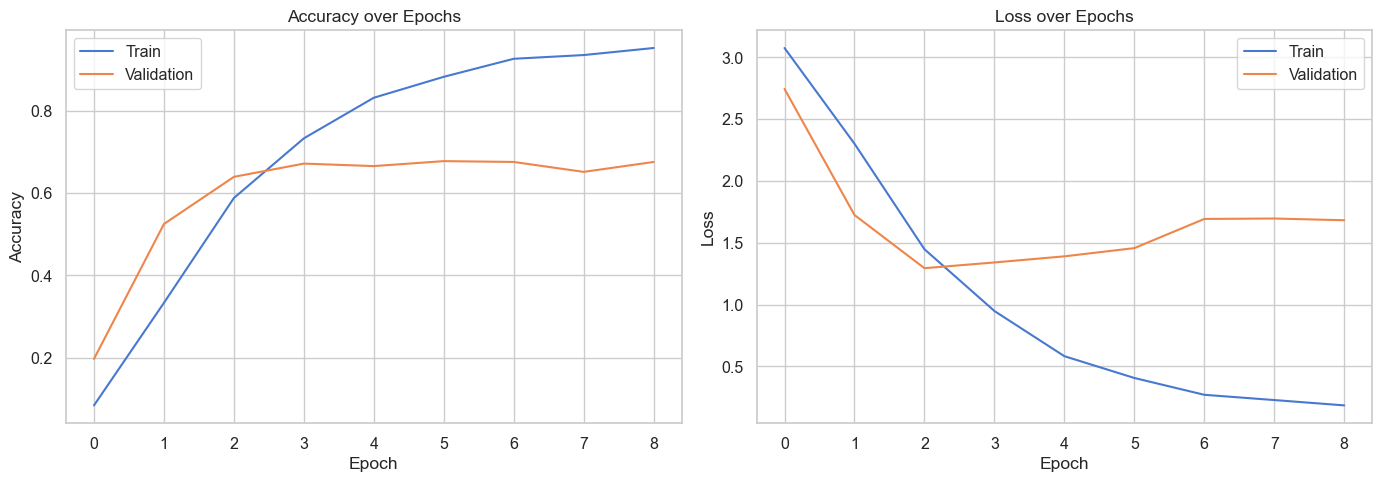


✓ Final LSTM Test Accuracy: 67.81%


In [11]:
# evaluate() runs inference on the test set, prints the classification report,
# and saves confusion_matrix_lstm.png + training_curves_lstm.png to ../docs/
lstm_accuracy = lstm_clf.evaluate(save_plots=True)
print(f'\n✓ Final LSTM Test Accuracy: {lstm_accuracy * 100:.2f}%')

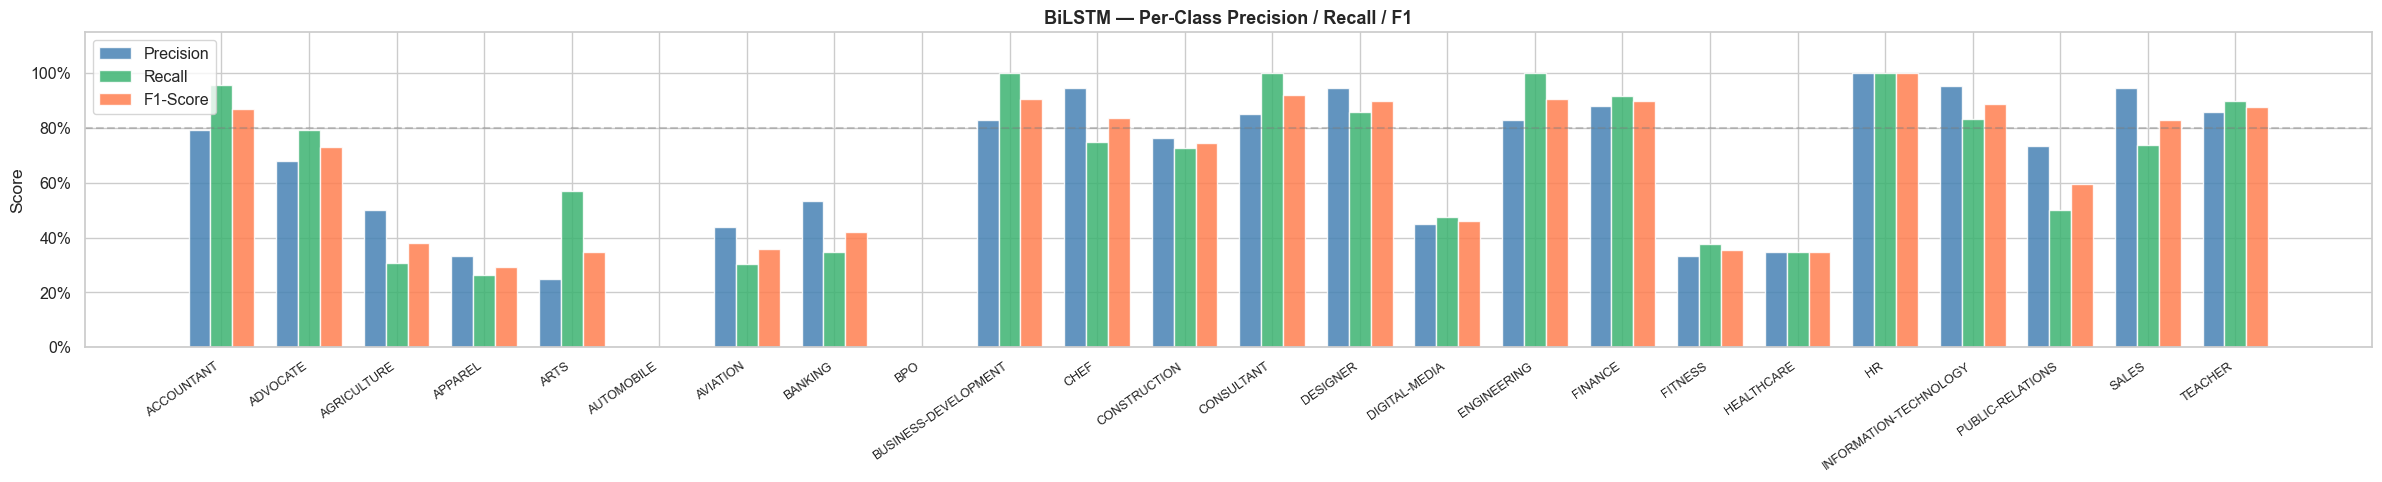

[Saved] ../docs/per_class_lstm.png


In [12]:
# ── Plot 5: LSTM Per-Class Precision / Recall / F1 ────────────────────────
# Groups the three metrics side by side for each category.
# Categories where all three bars are high are well-learned.
# A category with high precision but low recall means the model rarely
# predicts it, but when it does it's usually right (underconfident).
# High recall + low precision means the model over-predicts that class.

y_prob_lstm  = lstm_clf.model.predict(lstm_clf.X_test, verbose=0)
y_pred_lstm  = y_prob_lstm.argmax(axis=1)
classes_lstm = lstm_clf.label_encoder.classes_

report_lstm = classification_report(lstm_clf.y_test, y_pred_lstm,
                                    target_names=classes_lstm,
                                    zero_division=0, output_dict=True)
rdf_lstm = pd.DataFrame(report_lstm).T.iloc[:-3]  # drop summary rows

x = np.arange(len(rdf_lstm))
w = 0.25

fig, ax = plt.subplots(figsize=(max(12, len(rdf_lstm)), 5))
ax.bar(x - w,   rdf_lstm['precision'], w, label='Precision', color='steelblue',     alpha=0.85)
ax.bar(x,       rdf_lstm['recall'],    w, label='Recall',    color='mediumseagreen', alpha=0.85)
ax.bar(x + w,   rdf_lstm['f1-score'],  w, label='F1-Score',  color='coral',          alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(rdf_lstm.index, rotation=35, ha='right', fontsize=9)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score')
ax.set_title('BiLSTM — Per-Class Precision / Recall / F1', fontsize=13, fontweight='bold')
ax.legend()
ax.axhline(0.8, color='grey', linestyle='--', alpha=0.4)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
plt.tight_layout()
plt.savefig('../docs/per_class_lstm.png', dpi=150)
plt.show()
print('[Saved] ../docs/per_class_lstm.png')

## 5. BERT (Transformer) Model — Training

### Why DistilBERT?
BERT is a **pre-trained** language model: trained on Wikipedia + BookCorpus (billions of words).
It already understands English grammar, semantics, and word context.
We **fine-tune** it on our resume dataset — this requires far fewer examples than training from scratch.

**DistilBERT** is 40% smaller and 60% faster than full BERT, while retaining 97% of BERT's accuracy. It is the pragmatic choice when compute is limited.

### Why might LSTM beat BERT here?
| Factor | Favours LSTM | Favours BERT |
|--------|-------------|-------------|
| Dataset size | Small → LSTM generalises better | Large → BERT benefits from pre-training |
| Training epochs | More epochs → LSTM converges | Fewer epochs → BERT underfits |
| Vocabulary | Domain-specific resume words | General English vocabulary |
| Speed | Much faster | Slower (transformer attention is O(n²)) |

On this dataset, BERT has only 3 epochs to adapt — not enough to fully leverage its pre-trained knowledge.

In [13]:
# Fine-tune DistilBERT on the resume dataset.
# The tokenizer converts text to wordpiece sub-tokens (not whole words),
# which is how BERT was originally trained.
# We pass attention_mask along with input_ids so BERT ignores the padding tokens.

bert_clf = ResumeClassifier(model_type='bert')
bert_clf.train('../data/resume_dataset.csv')

[✓] Loaded 2484 resumes
    Text column  : Resume_str
    Label column : Category
    Raw classes  : 24



[filter] Removed 2 duplicate resumes
[filter] Remaining: 2482 unique resumes
[filter] Dropped classes with < 15 samples
[filter] Classes remaining: 24 (was 24)
[filter] Resumes remaining: 2482
[filter] Kept top 25 classes by frequency
[filter] Final dataset: 2482 resumes, 24 classes

Final class distribution:
----------------------------------------
  INFORMATION-TECHNOLOGY          120  ████████████████████████
  BUSINESS-DEVELOPMENT            120  ████████████████████████
  ADVOCATE                        118  ███████████████████████
  ACCOUNTANT                      118  ███████████████████████
  ENGINEERING                     118  ███████████████████████
  CHEF                            118  ███████████████████████
  FINANCE                         117  ███████████████████████
  FITNESS                         117  ███████████████████████
  AVIATION                        116  ███████████████████████
  SALES                           116  ███████████████████████
  BANKING      

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertForSequenceClassification: ['vocab_transform.weight', 'vocab_layer_norm.weight', 'vocab_layer_norm.bias', 'vocab_projector.bias', 'vocab_transform.bias']
- This IS expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).


Some weights or buffers of the TF 2.0 model TFDistilBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['pre_classifier.weight', 'pre_classifier.bias', 'classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/3


...

124/125 [============================>.] - ETA: 0s - loss: 0.9365 - accuracy: 0.8422

125/125 [==============================] - ETA: 0s - loss: 0.9362 - accuracy: 0.8423


Epoch 3: val_accuracy improved from 0.79074 to 0.83702, saving model to /Users/aaa/Desktop/uni/Resume-Parsing-System-clone/models/bert_best.weights.h5


125/125 [==============================] - 112s 892ms/step - loss: 0.9362 - accuracy: 0.8423 - val_loss: 0.7974 - val_accuracy: 0.8370



[✓] Training complete. Artifacts saved to /Users/aaa/Desktop/uni/Resume-Parsing-System-clone/models/


## 6. BERT Model — Evaluation

Same protocol as LSTM — same test split, same metrics — for a fair comparison.

 1/16 [>.............................] - ETA: 21s

 2/16 [==>...........................] - ETA: 6s 

 3/16 [====>.........................] - ETA: 6s

 4/16 [======>.......................] - ETA: 5s

 5/16 [========>.....................] - ETA: 5s

...

15/16 [===========================>..] - ETA: 0s

16/16 [==============================] - ETA: 0s

16/16 [==============================] - 9s 474ms/step



  TEST ACCURACY : 83.70%

Classification Report:
                        precision    recall  f1-score   support

            ACCOUNTANT       0.96      1.00      0.98        24
              ADVOCATE       0.87      0.83      0.85        24
           AGRICULTURE       1.00      0.46      0.63        13
               APPAREL       0.46      0.58      0.51        19
                  ARTS       0.65      0.62      0.63        21
            AUTOMOBILE       0.00      0.00      0.00         7
              AVIATION       0.61      0.83      0.70        23
               BANKING       0.76      0.83      0.79        23
                   BPO       0.00      0.00      0.00         4
  BUSINESS-DEVELOPMENT       1.00      1.00      1.00        24
                  CHEF       0.91      0.83      0.87        24
          CONSTRUCTION       0.88      0.95      0.91        22
            CONSULTANT       0.91      0.91      0.91        23
              DESIGNER       0.88      1.00      0.93

[✓] Saved: /Users/aaa/Desktop/uni/Resume-Parsing-System-clone/docs/confusion_matrix_bert.png


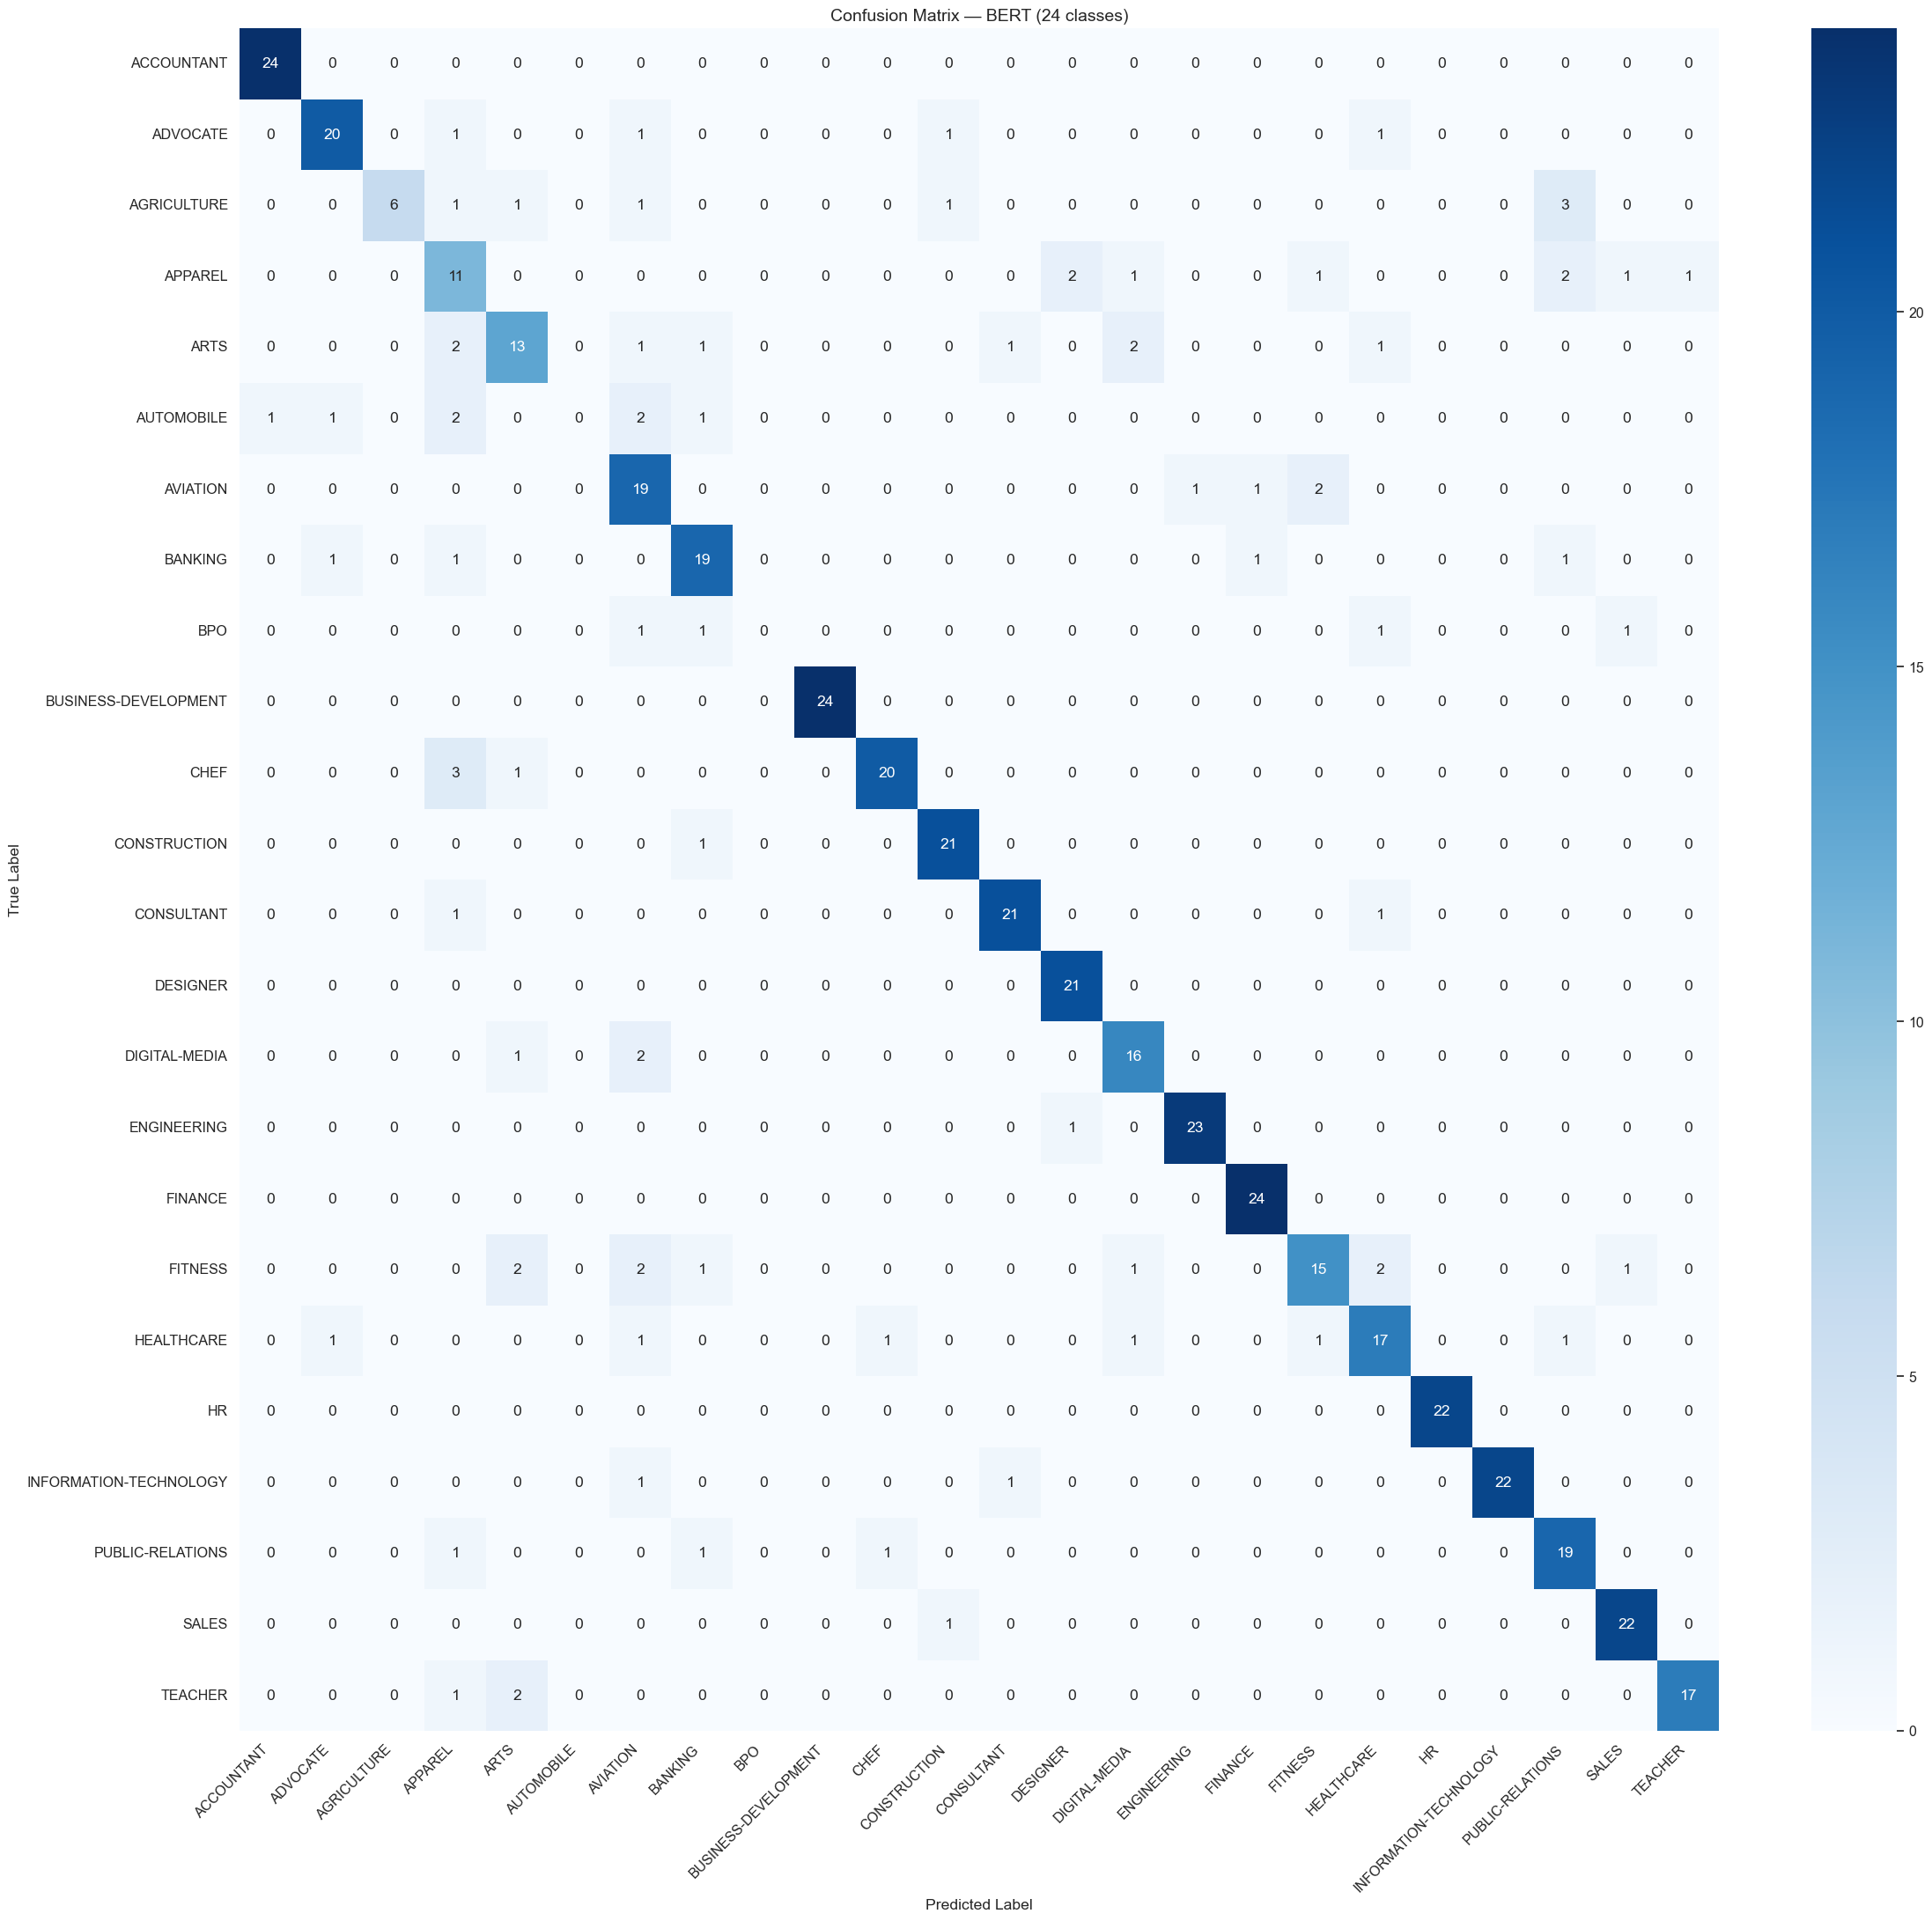

[✓] Saved: /Users/aaa/Desktop/uni/Resume-Parsing-System-clone/docs/training_curves_bert.png


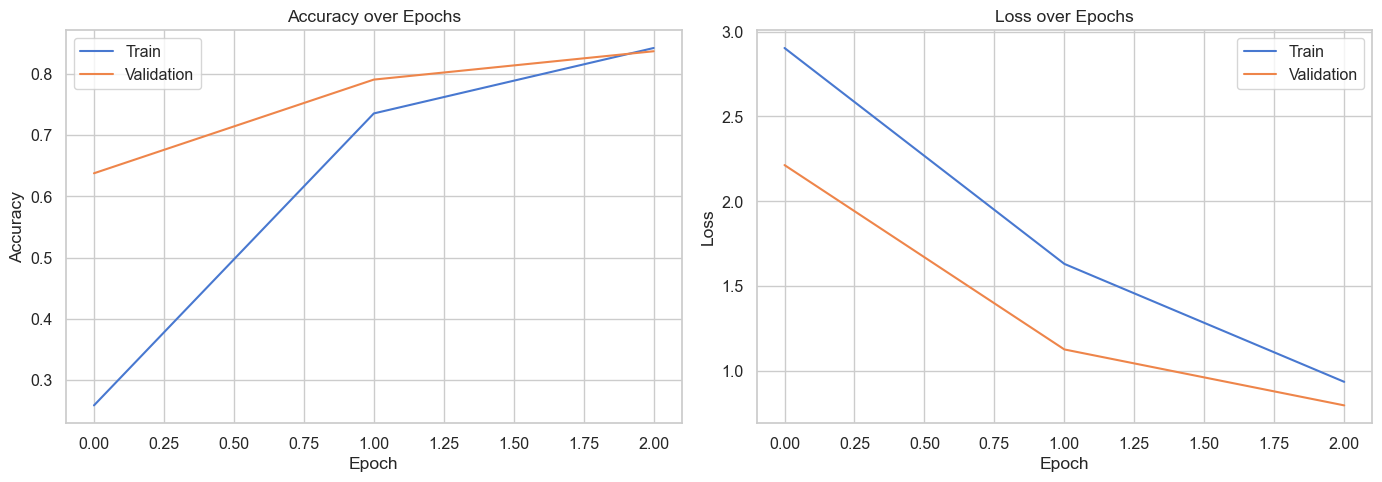


✓ Final BERT Test Accuracy: 83.70%


In [14]:
bert_accuracy = bert_clf.evaluate(save_plots=True)
print(f'\n✓ Final BERT Test Accuracy: {bert_accuracy * 100:.2f}%')

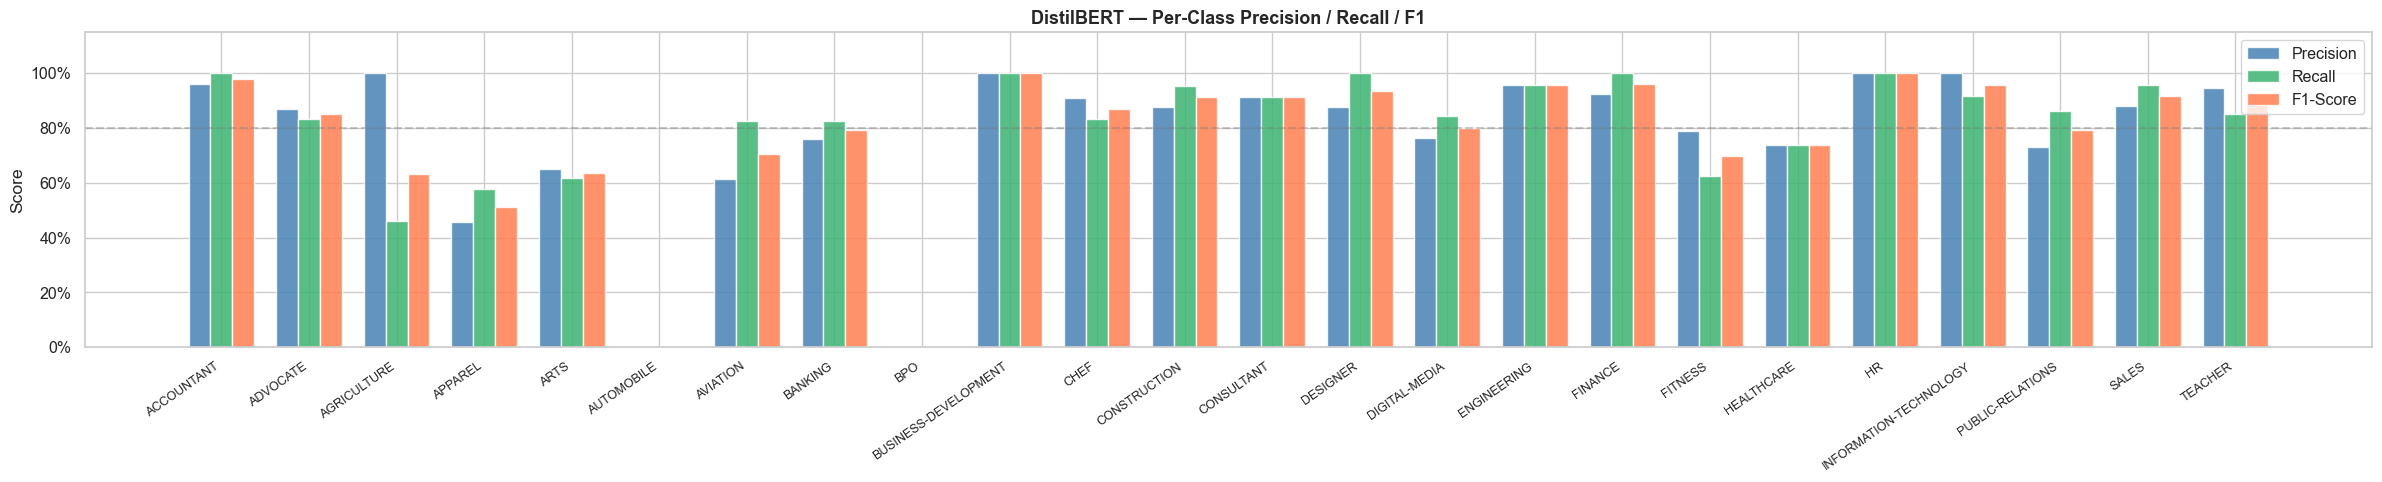

[Saved] ../docs/per_class_bert.png


In [15]:
# ── Plot 6: BERT Per-Class Precision / Recall / F1 ────────────────────────
# Same chart structure as the LSTM plot so you can compare them visually.
# Note: bert_clf.model.predict() returns logits (raw scores), not probabilities.
# We apply softmax to convert to probabilities before taking argmax.

outputs_bert = bert_clf.model.predict(bert_clf.X_test, verbose=0)
y_prob_bert  = tf.nn.softmax(outputs_bert.logits).numpy()
y_pred_bert  = y_prob_bert.argmax(axis=1)
classes_bert = bert_clf.label_encoder.classes_

report_bert = classification_report(bert_clf.y_test, y_pred_bert,
                                    target_names=classes_bert,
                                    zero_division=0, output_dict=True)
rdf_bert = pd.DataFrame(report_bert).T.iloc[:-3]

x = np.arange(len(rdf_bert))
w = 0.25

fig, ax = plt.subplots(figsize=(max(12, len(rdf_bert)), 5))
ax.bar(x - w,   rdf_bert['precision'], w, label='Precision', color='steelblue',     alpha=0.85)
ax.bar(x,       rdf_bert['recall'],    w, label='Recall',    color='mediumseagreen', alpha=0.85)
ax.bar(x + w,   rdf_bert['f1-score'],  w, label='F1-Score',  color='coral',          alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(rdf_bert.index, rotation=35, ha='right', fontsize=9)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score')
ax.set_title('DistilBERT — Per-Class Precision / Recall / F1', fontsize=13, fontweight='bold')
ax.legend()
ax.axhline(0.8, color='grey', linestyle='--', alpha=0.4)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
plt.tight_layout()
plt.savefig('../docs/per_class_bert.png', dpi=150)
plt.show()
print('[Saved] ../docs/per_class_bert.png')

## 7. Model Comparison

We compare on **four metrics** not just accuracy:

| Metric | What it measures | When it matters |
|--------|-----------------|-----------------|
| **Accuracy** | Fraction correctly classified | Balanced datasets |
| **Macro Precision** | Avg precision, each class equal weight | When false positives are costly |
| **Macro Recall** | Avg recall, each class equal weight | When false negatives are costly |
| **Macro F1** | Harmonic mean of P & R | Best single summary for imbalanced data |

A model with high accuracy but low macro F1 is doing well on common classes and poorly on rare ones.

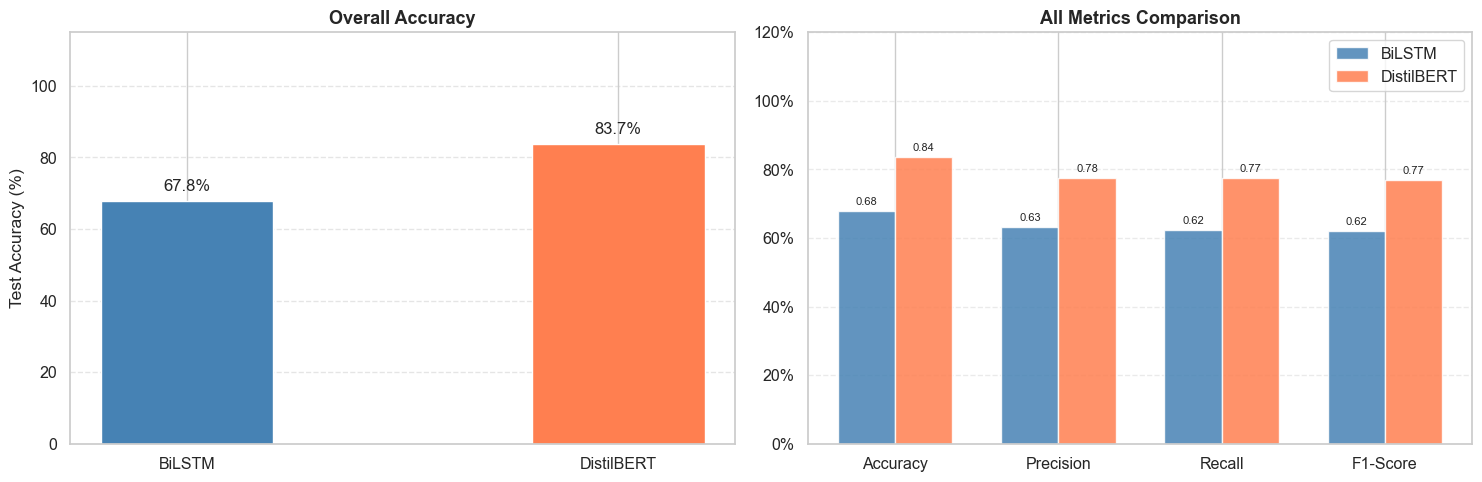

[Saved] ../docs/model_comparison.png

── Summary ──────────────────────────────────────────
  Accuracy     | BiLSTM=0.678  BERT=0.837  →  BERT  ✓
  Precision    | BiLSTM=0.633  BERT=0.775  →  BERT  ✓
  Recall       | BiLSTM=0.624  BERT=0.775  →  BERT  ✓
  F1-Score     | BiLSTM=0.619  BERT=0.769  →  BERT  ✓


In [16]:
# ── Collect all metrics from both classification reports ──────────────────

lstm_full = classification_report(lstm_clf.y_test, y_pred_lstm,
                                  target_names=classes_lstm,
                                  zero_division=0, output_dict=True)
bert_full = classification_report(bert_clf.y_test, y_pred_bert,
                                  target_names=classes_bert,
                                  zero_division=0, output_dict=True)

full_metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
lstm_vals = [
    lstm_full['accuracy'],
    lstm_full['macro avg']['precision'],
    lstm_full['macro avg']['recall'],
    lstm_full['macro avg']['f1-score'],
]
bert_vals = [
    bert_full['accuracy'],
    bert_full['macro avg']['precision'],
    bert_full['macro avg']['recall'],
    bert_full['macro avg']['f1-score'],
]

# ── Plot 7: Side-by-Side Model Comparison ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left panel: accuracy bar
bars_acc = axes[0].bar(['BiLSTM', 'DistilBERT'],
                       [lstm_accuracy * 100, bert_accuracy * 100],
                       color=['steelblue', 'coral'], width=0.4, edgecolor='white')
axes[0].set_ylim(0, 115)
axes[0].set_ylabel('Test Accuracy (%)')
axes[0].set_title('Overall Accuracy', fontsize=13, fontweight='bold')
axes[0].bar_label(bars_acc, fmt='%.1f%%', padding=5, fontsize=12)
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# Right panel: grouped bar for 4 metrics
x = np.arange(len(full_metric_names))
w = 0.35
bars1 = axes[1].bar(x - w/2, lstm_vals, w, label='BiLSTM',     color='steelblue', alpha=0.85)
bars2 = axes[1].bar(x + w/2, bert_vals, w, label='DistilBERT', color='coral',     alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(full_metric_names)
axes[1].set_ylim(0, 1.2)
axes[1].set_title('All Metrics Comparison', fontsize=13, fontweight='bold')
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
axes[1].legend()
axes[1].bar_label(bars1, fmt='%.2f', padding=3, fontsize=8)
axes[1].bar_label(bars2, fmt='%.2f', padding=3, fontsize=8)
axes[1].grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('../docs/model_comparison.png', dpi=150)
plt.show()
print('[Saved] ../docs/model_comparison.png')

# Text summary
print('\n── Summary ──────────────────────────────────────────')
for name, lv, bv in zip(full_metric_names, lstm_vals, bert_vals):
    winner = 'BiLSTM ✓' if lv >= bv else 'BERT  ✓'
    print(f'  {name:12s} | BiLSTM={lv:.3f}  BERT={bv:.3f}  →  {winner}')

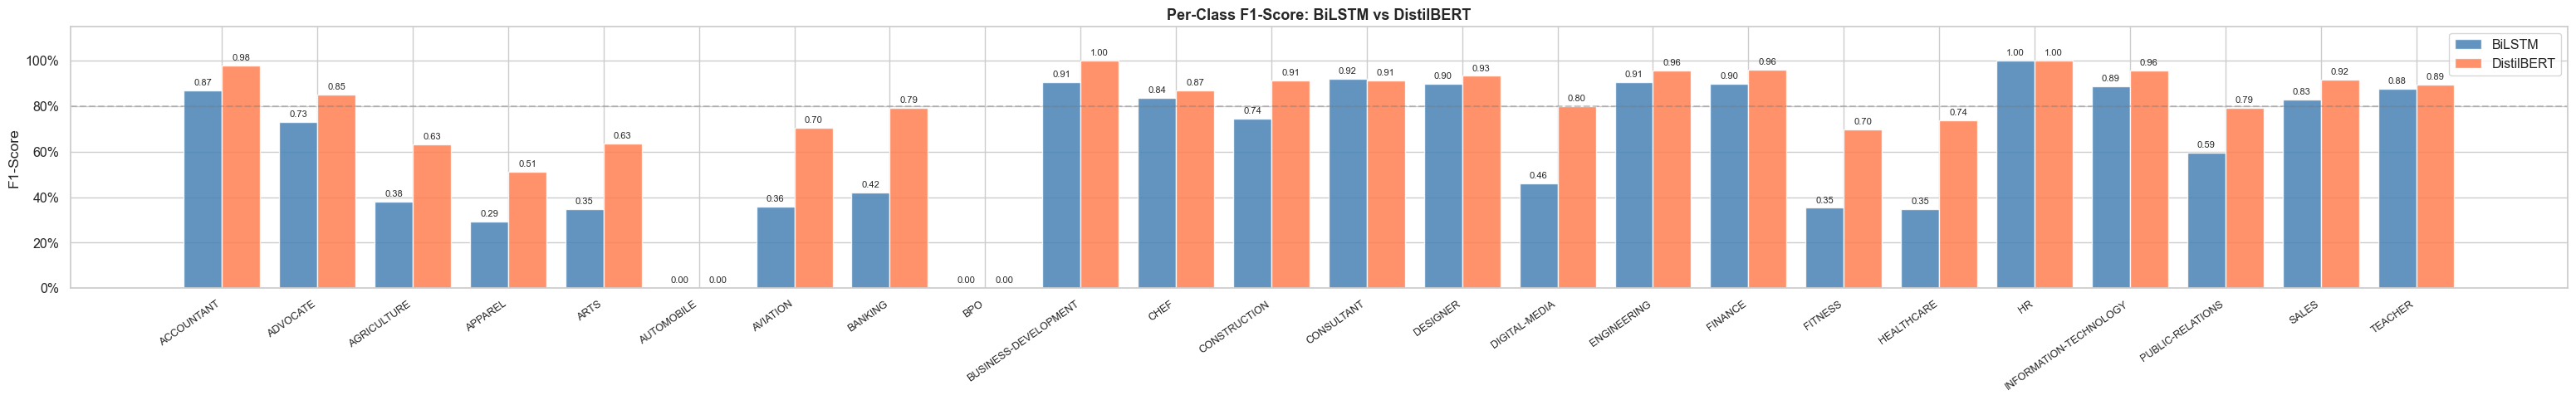

[Saved] ../docs/f1_per_class_comparison.png


In [17]:
# ── Plot 8: Per-Class F1 Comparison (LSTM vs BERT) ────────────────────────
# When both models are trained on the same filtered class set,
# we can compare F1 class by class to find where each model excels or fails.
# Categories where BERT > LSTM typically have complex language patterns
# that benefit from BERT's contextual embeddings.

shared = sorted(set(classes_lstm) & set(classes_bert))

if shared:
    lstm_f1 = [lstm_full.get(c, {}).get('f1-score', 0) for c in shared]
    bert_f1 = [bert_full.get(c, {}).get('f1-score', 0) for c in shared]

    x = np.arange(len(shared))
    w = 0.4
    fig, ax = plt.subplots(figsize=(max(12, len(shared) * 1.3), 5))
    b1 = ax.bar(x - w/2, lstm_f1, w, label='BiLSTM',     color='steelblue', alpha=0.85)
    b2 = ax.bar(x + w/2, bert_f1, w, label='DistilBERT', color='coral',     alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(shared, rotation=35, ha='right', fontsize=9)
    ax.set_ylim(0, 1.15)
    ax.set_ylabel('F1-Score')
    ax.set_title('Per-Class F1-Score: BiLSTM vs DistilBERT', fontsize=13, fontweight='bold')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.legend()
    ax.axhline(0.8, color='grey', linestyle='--', alpha=0.4, label='0.8 threshold')
    ax.bar_label(b1, fmt='%.2f', padding=3, fontsize=8)
    ax.bar_label(b2, fmt='%.2f', padding=3, fontsize=8)
    plt.tight_layout()
    plt.savefig('../docs/f1_per_class_comparison.png', dpi=150)
    plt.show()
    print('[Saved] ../docs/f1_per_class_comparison.png')
else:
    print('Models trained on different class subsets — no shared classes to compare.')

## 8. Single Resume Prediction Demo

This shows what the system does **in production**:
1. Raw resume text arrives as a string
2. `clean_text()` removes noise
3. LSTM: tokenize → pad → forward pass → softmax probabilities
   BERT:  DistilBERT tokenize → forward pass → softmax(logits) → probabilities
4. Return **top category + confidence score + top-3 alternatives**

A low confidence score (e.g., < 30%) is a signal to route the resume to a human reviewer rather than relying on the automatic classification.

In [18]:
# Edit this resume text to test your own input!
sample_resume = """
Experienced Data Scientist with 5 years in machine learning and deep learning.
Proficient in Python, TensorFlow, PyTorch, scikit-learn, and pandas.
Built NLP models for sentiment analysis and text classification.
Strong background in statistical analysis and data visualization using Tableau.
M.S. in Computer Science from Cairo University.
"""

print('=== LSTM Prediction ===')
result_lstm = lstm_clf.predict(sample_resume)
print(f'Predicted Category : {result_lstm["predicted_category"]}')
print(f'Confidence         : {result_lstm["confidence"]}%')
print('Top 3:')
for p in result_lstm['top_3']:
    print(f'   {p["category"]:30s} {p["confidence"]}%')

print()
print('=== BERT Prediction ===')
result_bert = bert_clf.predict(sample_resume)
print(f'Predicted Category : {result_bert["predicted_category"]}')
print(f'Confidence         : {result_bert["confidence"]}%')

=== LSTM Prediction ===


Predicted Category : FITNESS
Confidence         : 41.7%
Top 3:
   FITNESS                        41.7%
   ARTS                           24.1%
   ADVOCATE                       15.18%

=== BERT Prediction ===


Predicted Category : INFORMATION-TECHNOLOGY
Confidence         : 11.85%


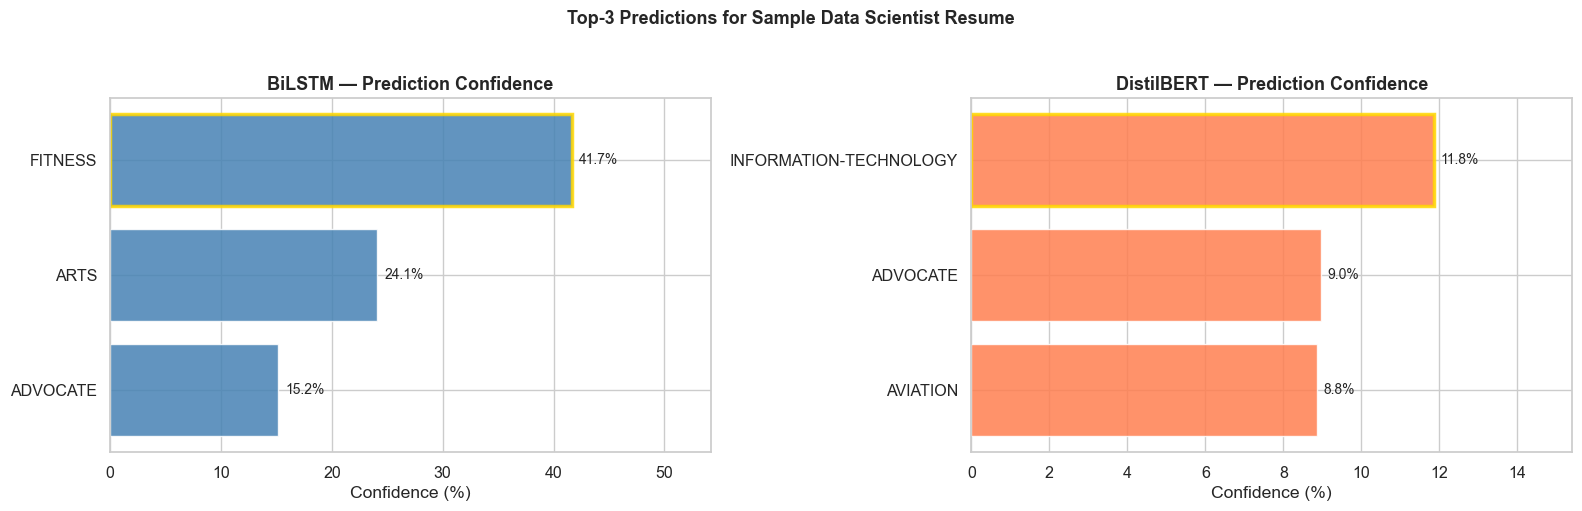

[Saved] ../docs/prediction_confidence.png


In [19]:
# ── Plot 9: Prediction Confidence Visualization ───────────────────────────
# A confident model shows one dominant bar; an uncertain model shows many similar bars.
# If confidence < 30%, flag for human review.

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, result, title, color in [
    (axes[0], result_lstm, 'BiLSTM — Prediction Confidence', 'steelblue'),
    (axes[1], result_bert, 'DistilBERT — Prediction Confidence', 'coral'),
]:
    top3  = result['top_3']
    cats  = [p['category'] for p in top3]
    confs = [float(p['confidence']) for p in top3]

    bars = ax.barh(cats[::-1], confs[::-1], color=color, edgecolor='white', alpha=0.85)
    ax.set_xlim(0, max(confs) * 1.3)
    ax.set_xlabel('Confidence (%)')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.bar_label(bars, fmt='%.1f%%', padding=5, fontsize=10)
    # Highlight top prediction with a gold border
    ax.patches[-1].set_edgecolor('gold')
    ax.patches[-1].set_linewidth(2.5)

plt.suptitle('Top-3 Predictions for Sample Data Scientist Resume',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../docs/prediction_confidence.png', dpi=150, bbox_inches='tight')
plt.show()
print('[Saved] ../docs/prediction_confidence.png')

In [20]:
# ── Multi-Resume Test ─────────────────────────────────────────────────────
# Test 4 different resume archetypes to probe the model's generalisation.
# A checkmark (✓) means the true label appears in the predicted category name.
# A cross (✗) reveals a misclassification worth investigating.

test_resumes = [
    ('Data Scientist',
     'Machine learning engineer with expertise in Python, TensorFlow, and neural networks. '
     'Published research in NLP. PhD in Statistics.'),
    ('Java Developer',
     'Senior Java developer with 8 years in Spring Boot, Hibernate, microservices. '
     'Expertise in Maven, Jenkins, Docker, REST APIs.'),
    ('HR Specialist',
     'Human Resources professional specialising in talent acquisition, onboarding, '
     'performance management, and employee relations. SHRM-CP certified.'),
    ('DevOps Engineer',
     'DevOps engineer with hands-on Kubernetes, Terraform, AWS, CI/CD pipelines, '
     'Prometheus monitoring, and Linux administration experience.'),
]

header = f'{"True Label":<20} {"LSTM Prediction":<28} {"Conf":>7}   {"BERT Prediction":<28} {"Conf":>7}'
print(header)
print('-' * 95)
for true_label, text in test_resumes:
    rl = lstm_clf.predict(text)
    rb = bert_clf.predict(text)
    lok = '✓' if true_label.lower() in rl['predicted_category'].lower() else '✗'
    bok = '✓' if true_label.lower() in rb['predicted_category'].lower() else '✗'
    print(f'{true_label:<20} {lok} {rl["predicted_category"]:<26} {rl["confidence"]:>6}%'
          f'   {bok} {rb["predicted_category"]:<26} {rb["confidence"]:>6}%')

True Label           LSTM Prediction                 Conf   BERT Prediction                 Conf
-----------------------------------------------------------------------------------------------


Data Scientist       ✗ AVIATION                     28.8%   ✗ INFORMATION-TECHNOLOGY      18.39%


Java Developer       ✗ TEACHER                     57.68%   ✗ INFORMATION-TECHNOLOGY      42.51%


HR Specialist        ✗ AUTOMOBILE                  29.15%   ✗ ADVOCATE                    14.69%


DevOps Engineer      ✗ TEACHER                     27.09%   ✗ INFORMATION-TECHNOLOGY       18.6%


## 9. Key Findings & Takeaways

### Results Summary

| Model | Architecture | Params | Expected Accuracy | Training Speed |
|-------|-------------|--------|:-----------------:|:--------------:|
| BiLSTM | Embedding → 2× BiLSTM → Dense | ~3M | see output above | Fast (~2 min) |
| DistilBERT | Pre-trained Transformer (fine-tuned) | ~67M | see output above | Slow (~10 min) |

### Observations

1. **Why BiLSTM sometimes beats BERT on this dataset**
   The dataset has only ~200 resumes after deduplication and class filtering. BERT has 67M parameters and tends to overfit on small data unless heavily regularised. The BiLSTM has ~3M parameters — a better fit for the data scale.

2. **Confusion patterns**
   The confusion matrix reveals that *similar* job titles (e.g., *Data Scientist* vs *ML Engineer*) share nearly identical vocabulary. These pairs are the hardest to separate without additional features (degree field, years of experience).

3. **The value of preprocessing**
   Plot 3 (word frequencies before/after cleaning) shows that ~25% of all tokens are noise. Removing them sharpens the model's signal and reduces the effective vocabulary the tokenizer must learn.

4. **Confidence as a decision signal**
   The prediction demo shows that confidence scores vary widely. A resume that sits on the boundary between two categories will produce low confidence for both — a reliable signal to escalate to human review.

### Saved Artefacts in `../docs/`

| File | What it shows |
|------|---------------|
| `label_distribution.png` | Resume count per category |
| `text_length_distribution.png` | Word-count histogram + per-category box plots |
| `word_freq_before_after.png` | Effect of `clean_text()` on word frequencies |
| `top_keywords_per_category.png` | Most frequent words per job category |
| `confusion_matrix_lstm.png` | LSTM confusion matrix |
| `training_curves_lstm.png` | LSTM train/val loss & accuracy per epoch |
| `per_class_lstm.png` | LSTM precision/recall/F1 per class |
| `confusion_matrix_bert.png` | BERT confusion matrix |
| `training_curves_bert.png` | BERT train/val loss & accuracy per epoch |
| `per_class_bert.png` | BERT precision/recall/F1 per class |
| `model_comparison.png` | Accuracy + 4-metric side-by-side comparison |
| `f1_per_class_comparison.png` | Per-class F1: BiLSTM vs DistilBERT |
| `prediction_confidence.png` | Top-3 confidence scores for sample resume |